In [2]:
import json
import numpy as np

fp = open("../archive/ch3/TestAccuracyForFiD_NQ_DEV_threshold0.8_K10_size1000.json")
data = json.load(fp)
fp.close()
fps = np.array(data["raw"]["pri_fusion_size"])
ex = np.array(data["raw"]["ex"])
ex_pub = np.array(data["raw"]["ex_pub"])
ex_pri = np.array(data["raw"]["ex_pri"])
f1 = np.array(data["raw"]["f1"])
f1_pub = np.array(data["raw"]["f1_pub"])
f1_pri = np.array(data["raw"]["f1_pri"])

In [6]:
fps = fps.reshape(2, -1, 1000)
flops = fps.sum(-1) * 768 

print(f"ex:\n {ex[1:].reshape(2, 5)}")
print(f"ex(%):\n {(ex / ex[0])[1:].reshape(2, -1).round(4) * 100}")
print(f"ex_pub(%):\n {(ex_pub / ex[0]).reshape(2, -1).round(4) * 100}")
print(f"ex_pri(%):\n {(ex_pri / ex[0]).reshape(2, -1).round(4) * 100}")

ex:
 [[0.409 0.392 0.389 0.403 0.411]
 [0.403 0.404 0.415 0.416 0.415]]
ex(%):
 [[97.85 93.78 93.06 96.41 98.33]
 [96.41 96.65 99.28 99.52 99.28]]
ex_pub(%):
 [[95.93 86.36 75.84 57.18 32.78]
 [95.93 86.36 75.84 57.18 32.78]]
ex_pri(%):
 [[32.06 61.96 82.78 89.95 96.65]
 [32.3  67.7  87.08 93.06 98.33]]


[0.73 2.45 6.36 5.38 0.  ]


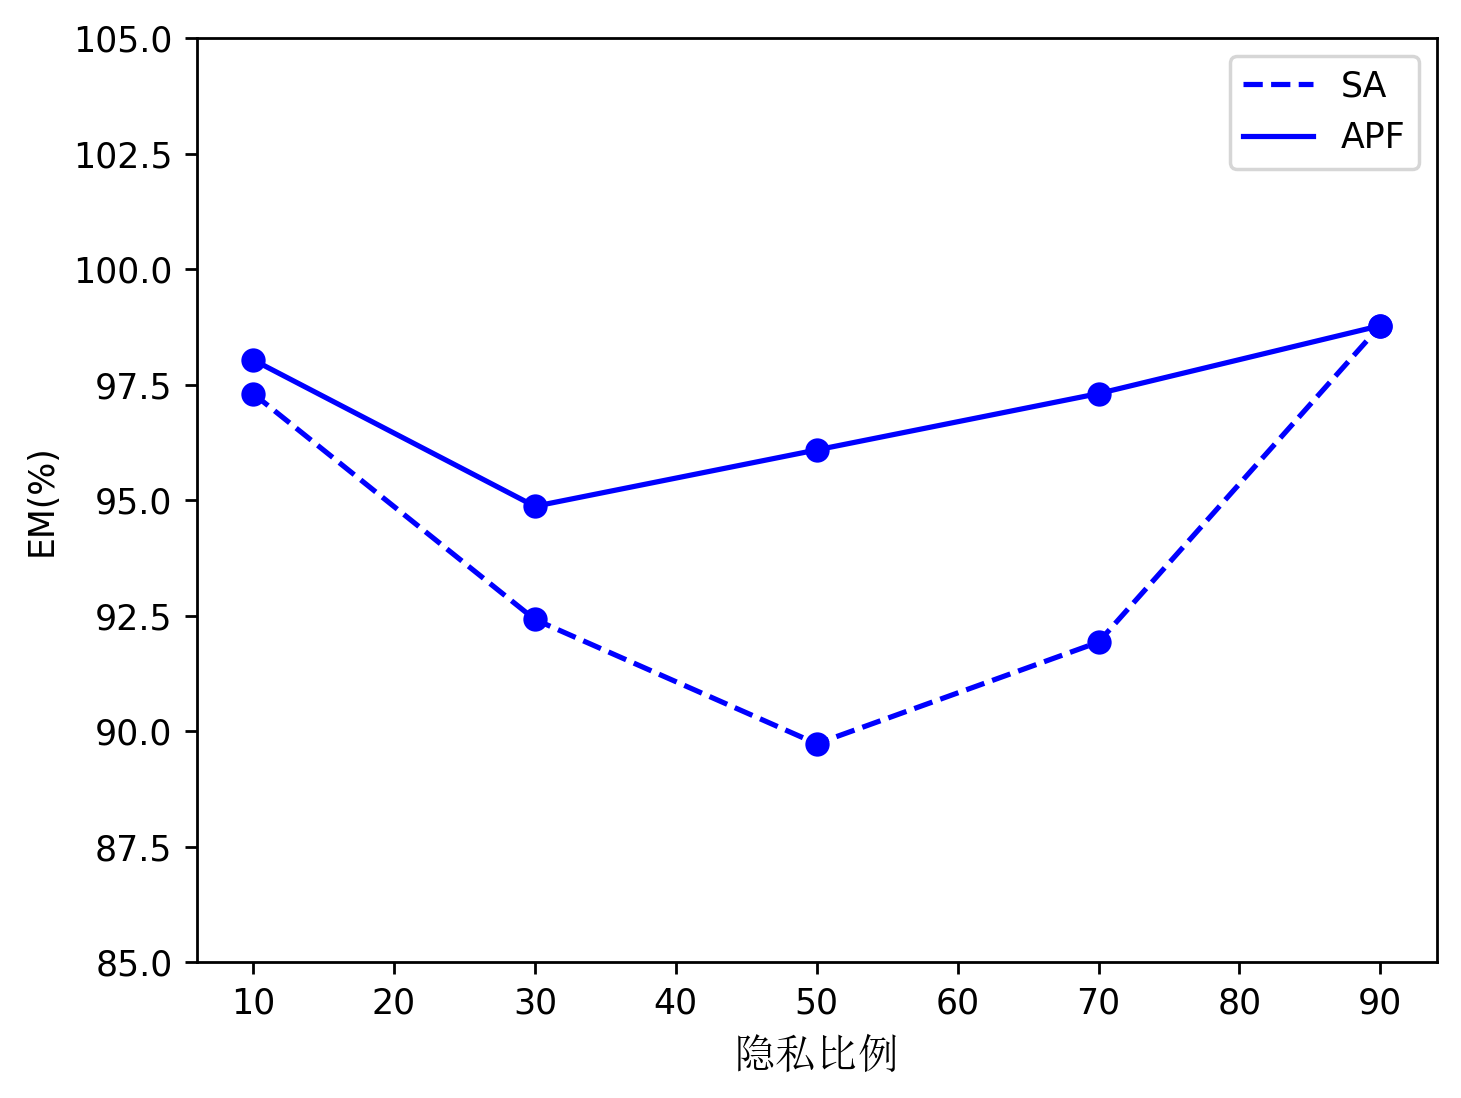

In [23]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

font_path = "../tmp/SimSun.ttc"
font = FontProperties(fname=font_path, size=12)


EM_TQA_K10_noadapt = (
    np.array([0.97310513, 0.92420538, 0.89731051, 0.9193154, 0.98777506]).round(4) * 100
)
EM_TQA_K10 = (
    np.array([0.9804401, 0.94865526, 0.9608802, 0.97310513, 0.98777506]).round(4) * 100
)
print(EM_TQA_K10 - EM_TQA_K10_noadapt)
x = np.linspace(10, 90, 5, dtype=int)
plt.figure(dpi=250)
plt.plot(x, EM_TQA_K10_noadapt, color="blue", linestyle="--", label="SA")
plt.scatter(x, EM_TQA_K10_noadapt, color="blue")
plt.plot(x, EM_TQA_K10, color="blue", label="APF")
plt.scatter(x, EM_TQA_K10, color="blue")
plt.ylim(85, 105)
plt.ylabel("EM(%)")
plt.xlabel("隐私比例", fontproperties=font)
plt.legend()

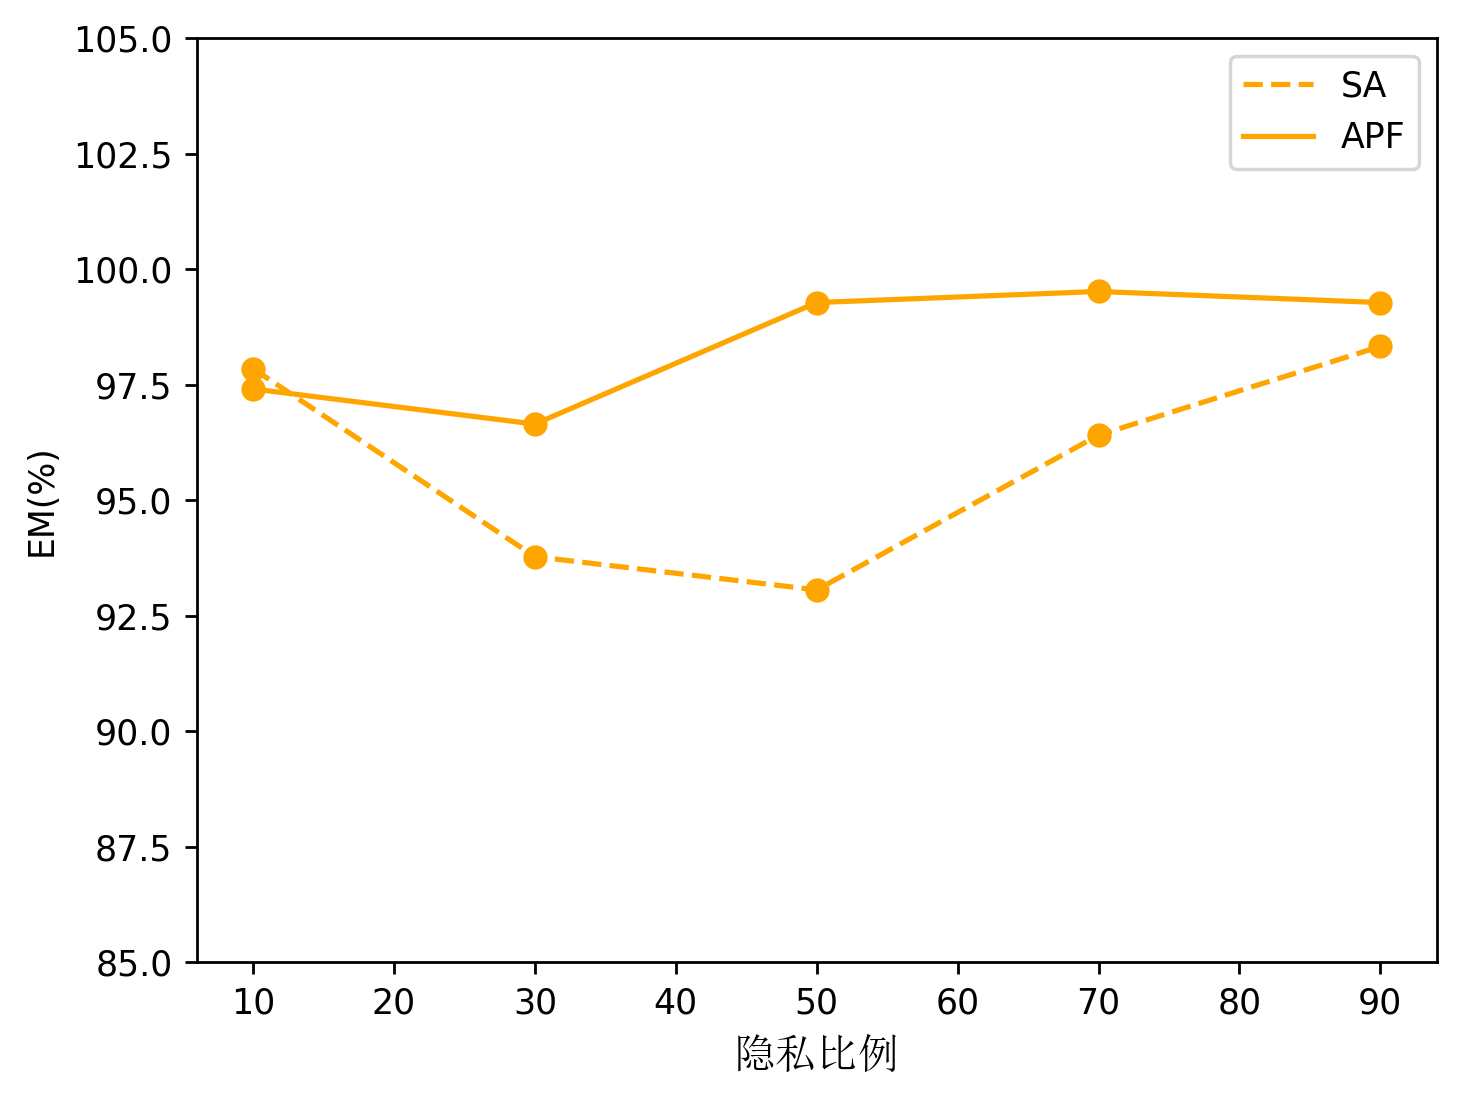

In [22]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

font_path = "../tmp/SimSun.ttc"
font = FontProperties(fname=font_path, size=12)


EM_NQ_K10_noadapt = [97.85, 93.78, 93.06, 96.41, 98.33]
EM_NQ_K10 = [97.41, 96.65, 99.28, 99.52, 99.28]
x = np.linspace(10, 90, 5, dtype=int)
plt.figure(dpi=250)
plt.plot(x, EM_NQ_K10_noadapt, color="orange", linestyle="--", label="SA")
plt.scatter(x, EM_NQ_K10_noadapt, color="orange")
plt.plot(x, EM_NQ_K10, color="orange", label="APF")
plt.scatter(x, EM_NQ_K10, color="orange")
plt.ylim(85, 105)
plt.ylabel("EM(%)")
plt.xlabel("隐私比例", fontproperties=font)
plt.legend()